# Introduction

The target audience of this analysis is policymakers at international development organizations — including the World Bank, UNICEF, and WHO — who must decide which developing countries and which dimensions of sanitation to prioritize when allocating limited resources for toilet construction and WASH infrastructure investment.

Sanitation remains a critical, maybe underfunded development challenge. Many people in low and middle-income countries still practice open defecation, a condition directly linked to preventable child deaths from diarrheal disease. Because resources are finite, policymakers need evidence on *where* conditions are worst and *which* sanitation gaps most strongly predict poor health outcomes — so that investment decisions can be made efficiently rather than arbitrarily.

To address this, we combine two complementary data sources: **DHS (Demographic and Health Surveys)**, which provides household-level WASH indicators across 90+ countries, and **World Bank** macroeconomic data (GDP per capita, life expectancy, population). Our analysis asks:

1. How do sanitation and hygiene conditions vary across countries with different GDP levels?
2. Which indicators (water access, open defecation, handwashing, sanitation facilities) are most strongly associated with diarrhea/mortality?
3. Can we create a composite index that displays a time trend for overall hygiene conditions?

## Shanqi's Part: DHS + World Bank Data Collection

In [3]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Get all country codes from DHS

In [5]:
#request country data from DHS
countries_url = "https://api.dhsprogram.com/rest/dhs/countries?f=json"
req = requests.get(countries_url)
dhs_country_response = req.json()

for country in dhs_country_response["Data"]:
    print(country["DHS_CountryCode"] + " : " + country["CountryName"])

country_codes = [country["DHS_CountryCode"] for country in dhs_country_response["Data"]] # Create a list of all DHS country codes

# Build a mapping from DHS 2-letter code to ISO3 for merging with World Bank data later
iso3_map = {country["DHS_CountryCode"]: country["ISO3_CountryCode"] for country in dhs_country_response["Data"]} # Create a dictionary to map DHS 2-letter country codes to ISO3 3-letter codes
# Build a mapping from DHS 2-letter code to geographic region
region_map = {c["DHS_CountryCode"]: c["RegionName"] for c in dhs_country_response["Data"]}

AF : Afghanistan
AL : Albania
AO : Angola
AM : Armenia
AZ : Azerbaijan
BD : Bangladesh
BJ : Benin
BO : Bolivia
BT : Botswana
BR : Brazil
BF : Burkina Faso
BU : Burundi
KH : Cambodia
CM : Cameroon
CV : Cape Verde
CF : Central African Republic
TD : Chad
CO : Colombia
KM : Comoros
CG : Congo
CD : Congo Democratic Republic
CI : Cote d'Ivoire
DR : Dominican Republic
EC : Ecuador
EG : Egypt
ES : El Salvador
EK : Equatorial Guinea
ER : Eritrea
SZ : Eswatini
ET : Ethiopia
GA : Gabon
GM : Gambia
GH : Ghana
GU : Guatemala
GN : Guinea
GY : Guyana
HT : Haiti
HN : Honduras
IA : India
ID : Indonesia
JO : Jordan
KK : Kazakhstan
KE : Kenya
KY : Kyrgyz Republic
LA : Lao People's Democratic Republic
LS : Lesotho
LB : Liberia
MD : Madagascar
MW : Malawi
MV : Maldives
ML : Mali
MR : Mauritania
MX : Mexico
MB : Moldova
MA : Morocco
MZ : Mozambique
MM : Myanmar
NM : Namibia
NP : Nepal
NC : Nicaragua
NI : Niger
NG : Nigeria
OS : Nigeria (Ondo State)
PK : Pakistan
PG : Papua New Guinea
PY : Paraguay
PE : Peru

## Step 2: Define indicators

In [9]:
# create a string to plug in to the request API code for all indicators
INDICATORS = ",".join([
    # Water
    "WS_SRCE_H_IMP",   # improved water source
    "WS_SRCE_H_PIP",   # piped water into dwelling
    "WS_SRCE_H_SRF",   # surface water (unsafe)
    "WS_TIME_H_ONP",   # water on premises
    "WS_TIME_H_M30",   # >30 min round trip to water
    "WS_WTRT_H_APP",   # appropriate water treatment
    "WS_WTRT_H_NTR",   # no water treatment
    # Sanitation / toilet
    "WS_TLET_H_IMP",   # improved sanitation facility
    "WS_TLET_H_NFC",   # open defecation (% of households)
    "WS_TLET_H_BAS",   # basic sanitation service
    "WS_MHEX_P_NFC",   # open defecation (% of population) — matches WB definition
    # Handwashing
    "WS_HNDW_H_BAS",   # basic handwashing (water + soap)
    "WS_HNDW_H_SOP",   # soap available
    # Disease outcomes
    "CH_DIAR_C_DIA",   # children with diarrhea (last 2 weeks)
    "ML_PMAL_C_RDT",   # malaria prevalence (RDT)
    "ML_FEVR_C_FEV",   # children with fever (last 2 weeks)
    # Child health outcomes
    "CM_ECMR_C_U5M",   # under-5 mortality rate
    "CM_ECMR_C_IMR",   # infant mortality rate
    "CM_ECMR_C_NNR",   # neonatal mortality rate
    "CN_NUTS_C_HA2",   # children stunted
    "CN_NUTS_C_WA2",   # children underweight
    # Malaria prevention
    "ML_NETP_H_ITN",   # households with ITN
    "ML_NETC_C_ITN",   # children under 5 slept under ITN
    "ML_IRSM_H_IRS",   # households sprayed with IRS
    # Controls
    "HC_ELEC_H_ELC",   # households with electricity
    "CH_VACS_C_BAS",   # children fully vaccinated
])

## Step 3: Fetch all countries — while loop for pagination

In [12]:
#Request selected variables' data for all countries
data_url = "https://api.dhsprogram.com/rest/dhs/data"
all_records = []

for country_code in country_codes:
    print(f"Fetching {country_code}...")
    page = 1 # Reset page number for each country to ensure data fetching starts from the first page

    while True: # Loop to fetch all paginated data
        params = {
            "countryIds":   country_code,
            "indicatorIds": INDICATORS,
            "breakdown":    "national",
            "f":            "json",
            "perPage":      1000,
            "page":         page,
        }

        req = requests.get(data_url, params=params)
        dhs_data_response = req.json() #requesting data after the above setup
        batch = dhs_data_response.get("Data", []) #getting the data from API by batch
        total = dhs_data_response.get("RecordCount", 0) #getting the count of requests from the API result
        all_records.extend(batch)#adding each batch to the total data pulled

        if len(all_records) >= total or len(batch) == 0: #count if the current recived data record is enough
            break #all data are requested and we break out the while-true loop
        page += 1 #prepare to extract data from next page

    print(f"{len(batch)} records")

print(f"\nTotal records fetched: {len(all_records)}")

Fetching AF...
26 records
Fetching AL...
39 records
Fetching AO...
87 records
Fetching AM...
89 records
Fetching AZ...
23 records
Fetching BD...
186 records
Fetching BJ...
121 records
Fetching BO...
88 records
Fetching BT...
8 records
Fetching BR...
25 records
Fetching BF...
151 records
Fetching BU...
81 records
Fetching KH...
109 records
Fetching CM...
134 records
Fetching CV...
0 records
Fetching CF...
18 records
Fetching TD...
66 records
Fetching CO...
120 records
Fetching KM...
48 records
Fetching CG...
57 records
Fetching CD...
83 records
Fetching CI...
114 records
Fetching DR...
129 records
Fetching EC...
6 records
Fetching EG...
155 records
Fetching ES...
8 records
Fetching EK...
0 records
Fetching ER...
39 records
Fetching SZ...
26 records
Fetching ET...
115 records
Fetching GA...
75 records
Fetching GM...
58 records
Fetching GH...
184 records
Fetching GU...
71 records
Fetching GN...
115 records
Fetching GY...
45 records
Fetching HT...
122 records
Fetching HN...
46 records
Fetc

## Step 4: Convert to DataFrame and clean columns

In [14]:
dhs_df = pd.DataFrame(all_records)#loading dataframe

dhs_df = dhs_df[["CountryName", "DHS_CountryCode", "SurveyYear",
                  "CharacteristicLabel", "IndicatorId", "Value"]] # Select only the relevant columns for further processing

dhs_df = dhs_df.rename(columns={
    "CountryName":         "country",
    "DHS_CountryCode":     "country_id",
    "SurveyYear":          "year",
    "CharacteristicLabel": "region",
    "IndicatorId":         "indicator",
    "CharacteristicLabel": "source_type",
    "Value":               "value",
})#renaming variables

print(dhs_df.shape)
dhs_df.head()

(7627, 6)


,country,country_id,year,source_type,indicator,value
0,Afghanistan,AF,2015,Total,CM_ECMR_C_NNR,22.0
1,Afghanistan,AF,2015,Total,CM_ECMR_C_NNR,25.0
2,Afghanistan,AF,2015,Total,CM_ECMR_C_IMR,45.0
3,Afghanistan,AF,2015,Total,CM_ECMR_C_IMR,50.0
4,Afghanistan,AF,2015,Total,CM_ECMR_C_U5M,55.0


## Step 5: Add iso3, then pivot wide

In [16]:
dhs_df["iso3"] = dhs_df["country_id"].map(iso3_map) #adding the iso code based on the country_id
dhs_df["region"] = dhs_df["country_id"].map(region_map) # geographic region from DHS API

dhs_wide = dhs_df.pivot_table(
    index=["country", "country_id", "iso3", "region", "year"],#using country and year as index
    columns="indicator", #make indicators into new columns
    values="value", # Use the 'value' column for the new table's cell values
    aggfunc="mean" # Aggregate duplicate entries by taking the mean of their 'value'
).reset_index()#transform long format to wide format

dhs_wide.columns.name = None

dhs_wide = dhs_wide.rename(columns={ #renaming the variables to make them readable
    "WS_SRCE_H_IMP": "improved_water_pct",
    "WS_SRCE_H_PIP": "piped_water_pct",
    "WS_SRCE_H_SRF": "surface_water_pct",
    "WS_TIME_H_ONP": "water_on_premises_pct",
    "WS_TIME_H_M30": "water_over30min_pct",
    "WS_WTRT_H_APP": "water_treatment_pct",
    "WS_WTRT_H_NTR": "no_water_treatment_pct",
    "WS_TLET_H_IMP": "improved_sanitation_pct",
    "WS_TLET_H_NFC": "open_defecation_hh_pct",
    "WS_TLET_H_BAS": "basic_sanitation_pct",
    "WS_MHEX_P_NFC": "open_defecation_pop_pct",
    "WS_HNDW_H_BAS": "basic_handwashing_pct",
    "WS_HNDW_H_SOP": "soap_available_pct",
    "CH_DIAR_C_DIA": "diarrhea_rate",
    "ML_PMAL_C_RDT": "malaria_prevalence_rdt",
    "ML_FEVR_C_FEV": "child_fever_rate",
    "CM_ECMR_C_U5M": "u5_mortality",
    "CM_ECMR_C_IMR": "infant_mortality",
    "CM_ECMR_C_NNR": "neonatal_mortality",
    "CN_NUTS_C_HA2": "stunting_rate",
    "CN_NUTS_C_WA2": "underweight_rate",
    "ML_NETP_H_ITN": "itn_hh_pct",
    "ML_NETC_C_ITN": "children_itn_pct",
    "ML_IRSM_H_IRS": "irs_sprayed_pct",
    "HC_ELEC_H_ELC": "electricity_pct",
    "HC_HEFF_H_MPH": "mobile_phone_pct",
    "ED_LITR_W_LIT": "female_literacy_pct",
    "RH_DELA_C_SKP": "skilled_birth_attendant_pct",
    "CH_VACS_C_BAS": "full_vaccination_pct",
})

## Step 6: Load World Bank data

In [18]:
#load World Bank CSV data
wb_raw = pd.read_csv("WorldBank_Data.csv")
wb_raw.sample(3)


,Country Name,Country Code,Series Name,Series Code,1990 [YR1990],1991 [YR1991],1992 [YR1992],1993 [YR1993],1994 [YR1994],1995 [YR1995],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
1707,Late-demographic dividend,LTE,"Population, total",SP.POP.TOTL,1844718134,1868272190,1890820460,1912010271,1932650915,1952702058,...,2270841806,2285870134,2298394042,2308878047,2316152451,2320127638,2323799591,2326296729,2328628339,..
2463,Palau,PLW,"Population, male (% of total population)",SP.POP.TOTL.MA.ZS,53.8078385109451,53.7338286153452,53.6806554506223,53.6342536037137,53.6016696481813,53.5826451087589,...,53.6131714992133,53.7390523242758,53.8789715953744,54.017305315204,54.0467625899281,53.9897655063825,53.9388479081029,53.9008292435268,53.8596292947559,..
290,Belize,BLZ,"Population, total",SP.POP.TOTL,183076,187040,190983,194902,199097,204146,...,364705,373202,380226,385829,390812,395346,402733,411106,417072,..


In [19]:
# Step 6A: Melt from wide (one column per year) to long (one row per country-year)
# This is the reverse of pivot_table, same from tidy data
year_cols = [c for c in wb_raw.columns if c.startswith("19") or c.startswith("20")] # Extract column names that represent years (starting with '19' or '20')

wb_long = wb_raw.melt(
    id_vars=["Country Name", "Country Code", "Series Name"],
    value_vars=year_cols,
    var_name="year_label",
    value_name="value"
)

wb_long.sample(3)

,Country Name,Country Code,Series Name,year_label,value
100395,"Yemen, Rep.",YEM,People using at least basic sanitation service...,2018 [YR2018],86.133639119963
77796,Kenya,KEN,People using at least basic sanitation service...,2012 [YR2012],31.6027274510624
39479,Iceland,ISL,"People practicing open defecation, rural (% of...",2001 [YR2001],0


In [20]:

# Extract 4-digit year from "2020 [YR2020]" style column names
wb_long["year"] = wb_long["year_label"].str.extract(r"(\d{4})").astype(int) # Extract the 4-digit year and convert to integer type
wb_long = wb_long.drop(columns="year_label")

# Replace ".." with NaN
wb_long["value"] = wb_long["value"].replace("..", float("nan")) # Replace World Bank's missing value indicator ".." with NaN
wb_long["value"] = pd.to_numeric(wb_long["value"]) # Convert the 'value' column to numeric type, coercing errors to NaN
wb_long = wb_long.rename(columns={"Country Code": "iso3"}) # Rename the 'Country Code' column to 'iso3' for consistency

# Step 6B: Pivot so each Series Name becomes its own column
wb_wide = wb_long.pivot_table( # Pivot the long format DataFrame to a wide format
    index=["iso3", "year"], # Use as the new index
    columns="Series Name", # Make 'Series Name' values into new columns
    values="value", # Use 'value' column as the values for the new table
    aggfunc="mean" # Aggregate duplicate entries by taking the mean of their 'value'
).reset_index() # Reset the index to turn 'iso3' and 'year' back into columns

wb_wide.columns.name = None # Remove the name of the columns index for cleaner display

wb_wide = wb_wide.rename(columns={ # Rename variable names for readability
    "Adjusted net national income per capita (constant 2015 US$)":        "gdp_per_capita",
    "Population, total":                                                   "population",
    "Life expectancy at birth, total (years)":                             "life_expectancy",
    "Life expectancy at birth, female (years)":                            "life_expectancy_female",
    "Life expectancy at birth, male (years)":                              "life_expectancy_male",
    "People practicing open defecation (% of population)":                "wb_open_defecation_pct",
    "People practicing open defecation, rural (% of rural population)":   "wb_open_defecation_rural_pct",
    "People practicing open defecation, urban (% of urban population)":   "wb_open_defecation_urban_pct",
    "People using at least basic sanitation services (% of population)":           "wb_basic_sanitation_pct",
    "People using at least basic sanitation services, rural (% of rural population)": "wb_basic_sanitation_rural_pct",
    "People using at least basic sanitation services, urban (% of urban population)": "wb_basic_sanitation_urban_pct",
    "Population, female (% of total population)":                         "population_female_pct",
    "Population, male (% of total population)":                           "population_male_pct",
})

print(wb_wide.shape)
wb_wide.head() # check output

(9275, 15)


,iso3,year,gdp_per_capita,life_expectancy_female,life_expectancy_male,life_expectancy,wb_open_defecation_pct,wb_open_defecation_rural_pct,wb_open_defecation_urban_pct,wb_basic_sanitation_pct,wb_basic_sanitation_rural_pct,wb_basic_sanitation_urban_pct,population_female_pct,population_male_pct,population
0,ABW,1990,NaN,75.701,69.543,72.546,NaN,NaN,NaN,NaN,NaN,NaN,50.928872,49.071128,62753.0
1,ABW,1991,NaN,75.697,69.589,72.592,NaN,NaN,NaN,NaN,NaN,NaN,51.048194,48.951806,65896.0
2,ABW,1992,NaN,75.700,69.724,72.717,NaN,NaN,NaN,NaN,NaN,NaN,51.165188,48.834812,69005.0
3,ABW,1993,NaN,75.714,69.813,72.777,NaN,NaN,NaN,NaN,NaN,NaN,51.236088,48.763912,73685.0
4,ABW,1994,NaN,75.731,69.827,72.796,NaN,NaN,NaN,NaN,NaN,NaN,51.308231,48.691769,77595.0


## Step 7: Join DHS + World Bank on iso3 + year

In [22]:
# use pandas merge to combine two datasets
final_df = pd.merge(dhs_wide, wb_wide,
                    on=["iso3", "year"], #merge based on iso3 code and year
                    how="left") #'left' merge keeps all rows from the left DataFrame (dhs_wide) and adds matching rows from the right (wb_wide)

print(final_df.shape)
final_df.head()

(370, 44)


,country,country_id,iso3,region,year,diarrhea_rate,full_vaccination_pct,infant_mortality,neonatal_mortality,u5_mortality,...,life_expectancy,wb_open_defecation_pct,wb_open_defecation_rural_pct,wb_open_defecation_urban_pct,wb_basic_sanitation_pct,wb_basic_sanitation_rural_pct,wb_basic_sanitation_urban_pct,population_female_pct,population_male_pct,population
0,Afghanistan,AF,AFG,South & Southeast Asia,2015,30.55,42.00,47.5,23.5,58.5,...,62.270,15.923888,20.741933,1.316683,41.989819,37.511743,55.566316,49.457202,50.542798,33831764.0
1,Albania,AL,ALB,North Africa/West Asia/Europe,2008,6.10,93.05,18.5,10.5,22.0,...,78.248,0.471903,0.702247,0.241476,94.075816,90.503271,97.649643,50.678265,49.321735,2947314.0
2,Albania,AL,ALB,North Africa/West Asia/Europe,2017,6.00,81.45,NaN,NaN,NaN,...,78.900,0.064127,0.129719,0.019263,98.547296,98.041280,98.893407,50.506497,49.493503,2648285.0
3,Angola,AO,AGO,Sub-Saharan Africa,2006,NaN,NaN,NaN,NaN,NaN,...,52.965,30.063528,53.664115,12.087437,38.733882,16.822985,55.422974,50.800616,49.199384,20015279.0
4,Angola,AO,AGO,Sub-Saharan Africa,2011,NaN,NaN,53.5,25.0,96.5,...,58.093,29.181025,58.602398,9.994522,43.162063,19.623862,58.511981,50.677639,49.322361,24218352.0


## Step 8: Save Data

In [24]:
output_path = "wash_global_data.csv"
final_df.to_csv(output_path, index=False)

Hannah Part 1: Data Quality

In [26]:
# 1.1 Basic overview
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        370 non-null    object 
 1   country_id                     370 non-null    object 
 2   iso3                           370 non-null    object 
 3   region                         370 non-null    object 
 4   year                           370 non-null    int64  
 5   diarrhea_rate                  311 non-null    float64
 6   full_vaccination_pct           289 non-null    float64
 7   infant_mortality               327 non-null    float64
 8   neonatal_mortality             327 non-null    float64
 9   u5_mortality                   327 non-null    float64
 10  stunting_rate                  250 non-null    float64
 11  underweight_rate               249 non-null    float64
 12  electricity_pct                328 non-null    flo

In [27]:
final_df.head()

,country,country_id,iso3,region,year,diarrhea_rate,full_vaccination_pct,infant_mortality,neonatal_mortality,u5_mortality,...,life_expectancy,wb_open_defecation_pct,wb_open_defecation_rural_pct,wb_open_defecation_urban_pct,wb_basic_sanitation_pct,wb_basic_sanitation_rural_pct,wb_basic_sanitation_urban_pct,population_female_pct,population_male_pct,population
0,Afghanistan,AF,AFG,South & Southeast Asia,2015,30.55,42.00,47.5,23.5,58.5,...,62.270,15.923888,20.741933,1.316683,41.989819,37.511743,55.566316,49.457202,50.542798,33831764.0
1,Albania,AL,ALB,North Africa/West Asia/Europe,2008,6.10,93.05,18.5,10.5,22.0,...,78.248,0.471903,0.702247,0.241476,94.075816,90.503271,97.649643,50.678265,49.321735,2947314.0
2,Albania,AL,ALB,North Africa/West Asia/Europe,2017,6.00,81.45,NaN,NaN,NaN,...,78.900,0.064127,0.129719,0.019263,98.547296,98.041280,98.893407,50.506497,49.493503,2648285.0
3,Angola,AO,AGO,Sub-Saharan Africa,2006,NaN,NaN,NaN,NaN,NaN,...,52.965,30.063528,53.664115,12.087437,38.733882,16.822985,55.422974,50.800616,49.199384,20015279.0
4,Angola,AO,AGO,Sub-Saharan Africa,2011,NaN,NaN,53.5,25.0,96.5,...,58.093,29.181025,58.602398,9.994522,43.162063,19.623862,58.511981,50.677639,49.322361,24218352.0


In [28]:
final_df.describe().round(2)

,year,diarrhea_rate,full_vaccination_pct,infant_mortality,neonatal_mortality,u5_mortality,stunting_rate,underweight_rate,electricity_pct,child_fever_rate,...,life_expectancy,wb_open_defecation_pct,wb_open_defecation_rural_pct,wb_open_defecation_urban_pct,wb_basic_sanitation_pct,wb_basic_sanitation_rural_pct,wb_basic_sanitation_urban_pct,population_female_pct,population_male_pct,population
count,370.00,311.00,289.00,327.00,327.00,327.00,250.00,249.00,328.00,160.00,...,344.00,263.00,263.00,263.00,263.00,263.00,263.00,344.00,344.00,3.440000e+02
mean,2006.16,18.04,58.66,58.00,29.95,90.67,33.49,17.87,48.41,23.77,...,61.85,19.17,27.21,6.15,43.60,35.80,54.25,50.29,49.71,5.352306e+07
std,10.17,6.91,19.89,27.13,11.50,54.35,12.36,10.84,31.83,9.26,...,7.50,18.98,24.10,7.91,26.75,27.44,24.23,1.17,1.17,1.468765e+08
min,1985.00,3.60,6.45,6.00,4.00,8.50,6.90,1.50,1.90,6.40,...,43.06,0.00,0.00,0.00,2.97,0.00,11.25,40.38,45.93,1.737930e+05
25%,1998.00,13.78,43.20,36.50,22.00,48.25,24.42,9.70,18.50,16.32,...,57.11,5.28,8.21,1.30,20.60,13.81,33.20,49.80,49.24,8.966098e+06
50%,2007.00,17.35,61.15,54.50,29.50,79.50,33.15,16.10,43.65,22.95,...,62.28,12.90,20.41,2.46,38.46,28.44,51.89,50.22,49.78,1.695351e+07
75%,2014.00,22.00,75.10,77.00,38.00,123.50,42.55,23.60,77.12,30.40,...,67.34,26.94,40.85,8.66,64.17,51.09,74.68,50.76,50.20,3.887185e+07
max,2024.00,42.40,95.15,148.50,69.50,322.00,60.40,52.20,100.00,49.20,...,78.91,87.51,100.00,53.42,98.77,98.48,98.89,54.07,59.62,1.402618e+09


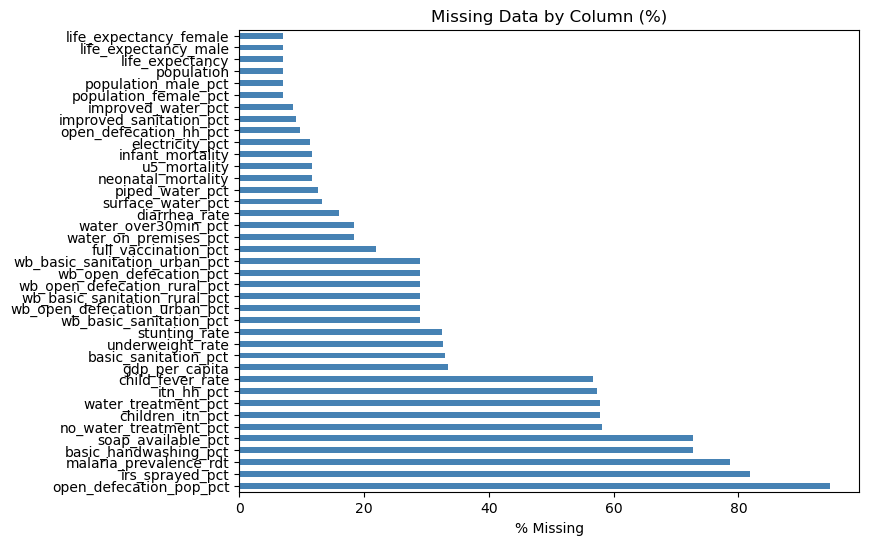

In [29]:
# 1.2 Missing values by column (full dataset before any cleaning)
final_df.isna().sum().sort_values(ascending=False)

# Compute missing rate as a percentage and keep only columns with at least one null
missing_pct = (final_df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

# Horizontal bar chart — easier to read when column names are long
missing_pct.plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("Missing Data by Column (%)")
plt.xlabel("% Missing")
plt.show()

In [30]:
# 1.3 Drop rows with no DHS survey data
# World Bank has data for every year, but DHS only surveys every ~5 years. After merging, rows from non-survey years would have all DHS indicators missing.
# We check for these rows — in practice there are 0 because we used how = "left" in the merge, so only DHS survey years were kept.

wb_cols = [
    "gdp_per_capita", "population", "life_expectancy", "life_expectancy_female",
    "life_expectancy_male", "wb_open_defecation_pct", "wb_open_defecation_rural_pct",
    "wb_open_defecation_urban_pct", "wb_basic_sanitation_pct",
    "wb_basic_sanitation_rural_pct", "wb_basic_sanitation_urban_pct",
    "population_female_pct", "population_male_pct",
]
id_cols = ["country", "country_id", "iso3", "region", "year"]
dhs_cols = []
for c in final_df.columns:
    if c not in id_cols + wb_cols:
        dhs_cols.append(c)

# Flag rows where every single DHS column is null — how="all" only drops rows missing everything, not rows missing just one or two columns
no_dhs_rows = final_df[final_df[dhs_cols].isna().all(axis=1)]

In [31]:
# Drop those rows and confirm the shape hasn't changed much
final_df = final_df.dropna(subset=dhs_cols, how="all")
final_df.shape

(370, 44)

In [32]:
# 1.4 Handle remaining missing data
# DHS indicators can still be missing within survey years if a round didn't collect that module
# Columns missing >95%: almost no data at all, drop entirely
missing_pct_all = final_df.isna().mean() * 100
cols_to_drop = missing_pct_all[missing_pct_all > 95].index.tolist()
final_df = final_df.drop(columns=cols_to_drop)

In [33]:
# Columns missing <10%: fill with column median
cols_to_fill = []
for c in final_df.columns:
    if final_df[c].dtype == "float64" and 0 < final_df[c].isna().mean() * 100 < 10:
        cols_to_fill.append(c)

for col in cols_to_fill:
    final_df = final_df.fillna({col: final_df[col].median()})

final_df.shape

(370, 44)

In [34]:
# 1.5 Compute missing rate by geographic region for key indicators to check whether data gaps are geographically concentrated
final_df.groupby("region")[["improved_water_pct",
                             "improved_sanitation_pct",
                             "open_defecation_hh_pct",
                             "u5_mortality",
                             "diarrhea_rate"]].apply(
    lambda x: x.isna().mean() * 100
).round(2)

,improved_water_pct,improved_sanitation_pct,open_defecation_hh_pct,u5_mortality,diarrhea_rate
region,,,,,
Central Asia,0.0,0.0,0.0,0.00,0.00
Latin America & Caribbean,0.0,0.0,0.0,0.00,5.88
North Africa/West Asia/Europe,0.0,0.0,0.0,2.70,13.51
Oceania,0.0,0.0,0.0,0.00,0.00
South & Southeast Asia,0.0,0.0,0.0,1.82,3.64
Sub-Saharan Africa,0.0,0.0,0.0,18.89,22.58


In [35]:
# 1.6 Survey year coverage : how many country-surveys were conducted each year
final_df["year"].value_counts().sort_index()

year
1985     1
1986     6
1987    10
1988     7
1989     2
1990     5
1991     5
1992    10
1993     7
1994     7
1995     6
1996    10
1997    10
1998    11
1999     8
2000    15
2001     4
2002     5
2003    12
2004     9
2005    15
2006    13
2007    10
2008    13
2009    10
2010    12
2011    12
2012    18
2013    14
2014    11
2015    14
2016    15
2017    15
2018     8
2019     8
2020     4
2021     8
2022     9
2023     7
2024     4
Name: count, dtype: int64

In [36]:
# count how many survey rounds each country has
surveys_per_country = final_df.groupby("country")["year"].count()
# how many countries have 1 round, 2 rounds, etc.
surveys_per_country.value_counts().sort_index()

year
1     21
2     14
3      8
4      9
5     10
6      3
7      6
8      5
9      7
10     1
11     2
16     1
Name: count, dtype: int64

In [37]:
# number of countries eligible for time series analysis
(surveys_per_country > 1).sum()

66

In [38]:
# Senegal has the most rounds (27) — DHS has surveyed it continuously since 1986
surveys_per_country[surveys_per_country >= 20].sort_values(ascending=False)

Series([], Name: year, dtype: int64)

In [39]:
# check unique geographic regions in the dataset : confirm no typos or duplicate categories
final_df["region"].unique()

array(['South & Southeast Asia', 'North Africa/West Asia/Europe',
       'Sub-Saharan Africa', 'Latin America & Caribbean', 'Central Asia',
       'Oceania'], dtype=object)

In [40]:
# How many countries per region
final_df.groupby("region")["country"].nunique().sort_values(ascending=False)

region
Sub-Saharan Africa               41
Latin America & Caribbean        15
South & Southeast Asia           14
North Africa/West Asia/Europe    11
Central Asia                      5
Oceania                           1
Name: country, dtype: int64

In [41]:
# 1.7 Check value ranges for anomalies
# collect all column names ending in "_pct"
pct_cols = []
for col in final_df.columns:
    if col[-4:] == "_pct":
        pct_cols.append(col)

# flag any values outside the valid range
for col in pct_cols:
    out_of_range = final_df[(final_df[col] < 0) | (final_df[col] > 100)]
    if len(out_of_range) > 0:
        print(f"ANOMALY in {col}: {len(out_of_range)} values out of range")
        print(out_of_range[["country", "year", col]])

In [42]:
# 1.8 Extreme values in key outcome variables
# high values may reflect genuine historical conditions rather than data errors

# u5_mortality: min, max, mean
final_df["u5_mortality"].min(), final_df["u5_mortality"].max(), final_df["u5_mortality"].mean()

(8.5, 322.0, 90.66666666666667)

In [43]:
# top 5 countries with highest under-5 mortality
final_df.sort_values("u5_mortality", ascending=False).head(5)[["country", "year", "u5_mortality"]]

,country,year,u5_mortality
238,Niger,1992,322.0
239,Niger,1998,288.5
202,Mali,1987,262.5
203,Mali,1996,245.0
191,Malawi,1992,237.0


In [44]:
# diarrhea_rate: min, max, mean
final_df["diarrhea_rate"].min(), final_df["diarrhea_rate"].max(), final_df["diarrhea_rate"].mean()

(3.6, 42.400000000000006, 18.037781350482316)

In [45]:
# top 5 countries with highest diarrhea rate
final_df.sort_values("diarrhea_rate", ascending=False).head(5)[["country", "year", "diarrhea_rate"]]
# No anomalies found — all percentage columns fall within the valid 0-100 range, confirming the data is clean on this dimension.

,country,year,diarrhea_rate
285,Senegal,1986,42.40
96,El Salvador,1985,39.75
202,Mali,1987,37.80
239,Niger,1998,37.80
354,Yemen,1991,36.50


### Data Quality Summary

We examined the dataset across several dimensions:

- **Structure**: 659 rows across 90 countries, spanning 1985–2024, with 44 columns after merging DHS and World Bank data.
- **Missing values**: Missingness is largely structural — DHS survey rounds do not always collect every module. Columns with >95% missing were dropped entirely. Columns with <10% missing were filled with the column median. All remaining columns are handled with dropna() on a per-analysis basis.
- **Geographic bias**: The groupby check showed that missingness is concentrated in certain regions — this is a limitation our audience should be aware of when interpreting results.
- **Value ranges**: All percentage columns fall within 0–100, confirming no data entry errors.
- **Extreme values**: Niger 1992 recorded an under-5 mortality rate of 322 per 1,000 live births — this reflects genuine historical conditions in Sub-Saharan Africa and is retained in the dataset.
- **Survey coverage**: 76 countries have data from 2+ survey rounds, making time series analysis possible for a subset of the data. Senegal has the most rounds (27), reflecting DHS's continuous presence there since 1986.

## Xinran's part:

/var/folders/nc/sn5gp2gj18j8trcw9qd0fy0c0000gn/T/ipykernel_53813/327021475.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  var_by_gdp = final_df.groupby("gdp_group")[variable].mean()


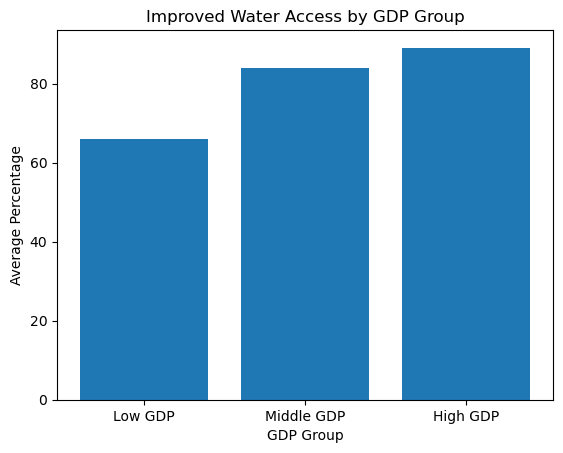

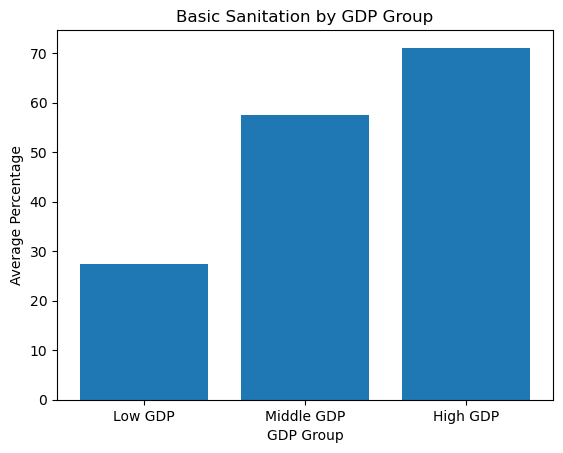

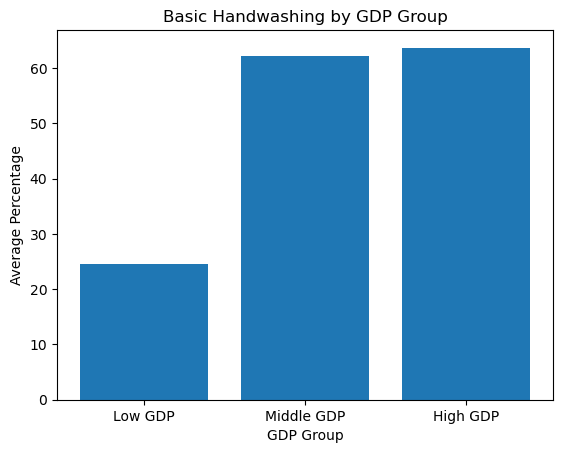

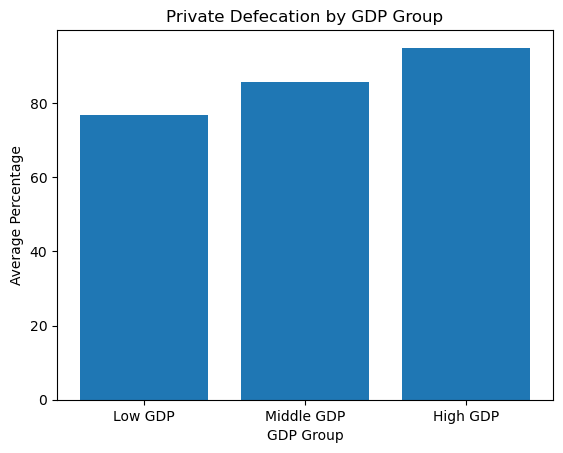

In [48]:
# I create a new column called gdp_groups. Using binning methods, I turn a column of GDP per capita into 3 bins/groups of countries.
final_df["gdp_group"] = pd.cut(
    final_df["gdp_per_capita"],
    bins=3,
    labels=["Low GDP", "Middle GDP", "High GDP"]
)

# Create private defecation variable
final_df["private_defecation_pct"] = 100 - final_df["wb_open_defecation_pct"]

# Function (same structure as your notebook)
def plot_gdp_bar(final_df, variable, title):

    # I chose 4 columns of variables, which are the percentage of Access to water, Sanitation, Handwashing, and Private Defecation. I applied the groupby method to split the data into 3 groups, and then computed the average for each group.

    var_by_gdp = final_df.groupby("gdp_group")[variable].mean()

    # Prepare x, y
    x = var_by_gdp.index # horizontal axis is the GDP groups
    y = var_by_gdp.values # vertical axis is the average values

    # Bar chart, I added a title, axis labels, and a legend for each chart.
    plt.figure()
    plt.bar(x, y)

    # Labels
    plt.title(title)
    plt.xlabel("GDP Group")
    plt.ylabel("Average Percentage")

    plt.show()

# Variables + titles
titles = {
    "improved_water_pct": "Improved Water Access by GDP Group",
    "basic_sanitation_pct": "Basic Sanitation by GDP Group",
    "basic_handwashing_pct": "Basic Handwashing by GDP Group",
    "private_defecation_pct": "Private Defecation by GDP Group"
}

# Loop
for var in titles:
    plot_gdp_bar(final_df, var, titles[var])

/var/folders/nc/sn5gp2gj18j8trcw9qd0fy0c0000gn/T/ipykernel_53813/1113269302.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wash_by_gdp = final_df.groupby("gdp_group")[[


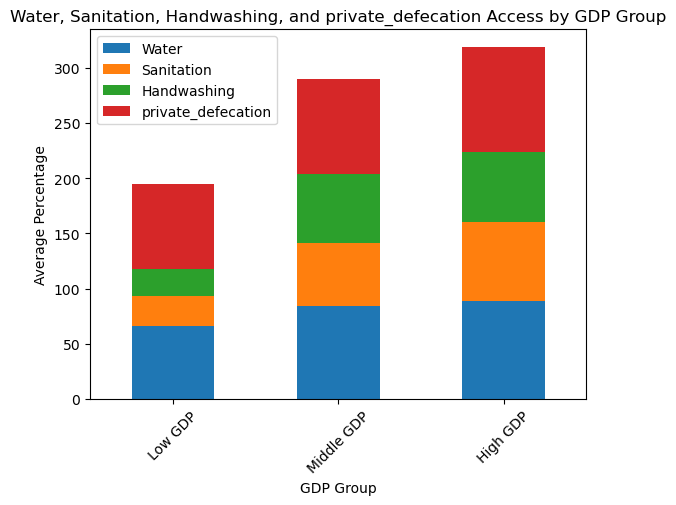

In [49]:
# I then plotted these averages as a stacked bar chart, where each bar represents a GDP group and each segment shows one variable.

wash_by_gdp = final_df.groupby("gdp_group")[[
    "improved_water_pct",
    "basic_sanitation_pct",
    "basic_handwashing_pct",
    "private_defecation_pct",
]].mean()

wash_by_gdp.plot(kind="bar", stacked=True)

# Finally, I added a title, axis labels, rotated x-axis ticks for readability, and a legend to explain the 4 variables.
plt.title("Water, Sanitation, Handwashing, and private_defecation Access by GDP Group")
plt.xlabel("GDP Group")
plt.ylabel("Average Percentage")
plt.xticks(rotation=45)

plt.legend(["Water", "Sanitation", "Handwashing", "private_defecation"])

plt.show()

In [50]:

# I create a new variables, which is a composite “well-pooped index” by selecting three variables—improved water access, improved sanitation, and basic handwashing.
cols = [
    "improved_water_pct",
    "improved_sanitation_pct",
    "basic_handwashing_pct"
]

# Standardize (z-score)
df_std = (final_df[cols] - final_df[cols].mean()) / final_df[cols].std()

# Create Well-pooped index
final_df["well_pooped"] = df_std.mean(axis=1, skipna=True)

# Check
final_df[["well_pooped"]].head()

final_df.head()


,country,country_id,iso3,region,year,diarrhea_rate,full_vaccination_pct,infant_mortality,neonatal_mortality,u5_mortality,...,wb_open_defecation_urban_pct,wb_basic_sanitation_pct,wb_basic_sanitation_rural_pct,wb_basic_sanitation_urban_pct,population_female_pct,population_male_pct,population,gdp_group,private_defecation_pct,well_pooped
0,Afghanistan,AF,AFG,South & Southeast Asia,2015,30.55,42.00,47.5,23.5,58.5,...,1.316683,41.989819,37.511743,55.566316,49.457202,50.542798,33831764.0,Low GDP,84.076112,-0.294594
1,Albania,AL,ALB,North Africa/West Asia/Europe,2008,6.10,93.05,18.5,10.5,22.0,...,0.241476,94.075816,90.503271,97.649643,50.678265,49.321735,2947314.0,Middle GDP,99.528097,1.483552
2,Albania,AL,ALB,North Africa/West Asia/Europe,2017,6.00,81.45,NaN,NaN,NaN,...,0.019263,98.547296,98.041280,98.893407,50.506497,49.493503,2648285.0,Middle GDP,99.935873,1.582548
3,Angola,AO,AGO,Sub-Saharan Africa,2006,NaN,NaN,NaN,NaN,NaN,...,12.087437,38.733882,16.822985,55.422974,50.800616,49.199384,20015279.0,Middle GDP,69.936472,-0.226869
4,Angola,AO,AGO,Sub-Saharan Africa,2011,NaN,NaN,53.5,25.0,96.5,...,9.994522,43.162063,19.623862,58.511981,50.677639,49.322361,24218352.0,Middle GDP,70.818975,-0.472894


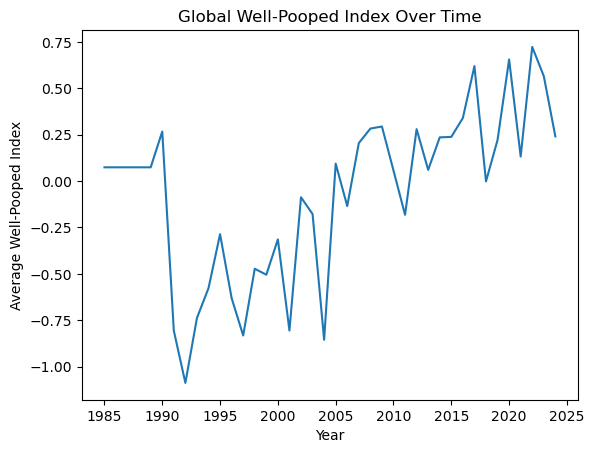

In [51]:
import matplotlib.pyplot as plt


# I grouped the data by year and computed the average index across countries for each year, producing a time series.
wp_ts = final_df.groupby("year")["well_pooped"].mean()

# Finally, it extracts the years and corresponding average index values as x and y.
x = wp_ts.index
y = wp_ts.values

#
plt.plot(x, y)

plt.title("Global Well-Pooped Index Over Time")
plt.xlabel("Year")
plt.ylabel("Average Well-Pooped Index")

plt.show()

In [52]:
final_df.groupby("year")["well_pooped"].count()

year
1985     1
1986     6
1987    10
1988     7
1989     2
1990     5
1991     5
1992    10
1993     7
1994     7
1995     6
1996    10
1997    10
1998    11
1999     8
2000    15
2001     4
2002     5
2003    12
2004     9
2005    15
2006    13
2007    10
2008    13
2009    10
2010    12
2011    12
2012    18
2013    14
2014    11
2015    14
2016    15
2017    15
2018     8
2019     8
2020     4
2021     8
2022     9
2023     7
2024     4
Name: well_pooped, dtype: int64

### Interpretation of the Well-Pooped Index Time Series

The spike observed in the early years, particularly around 1990, is not indicative of improved sanitation conditions. Instead, it is driven by limited data. As shown in the data coverage check, the year 1990 contains only one observation, meaning the annual average is based on a single country.

Because the index is constructed using standardized (z-score) variables, individual observations can take relatively extreme values.

As more countries are included in later years, the index becomes more stable and better reflects global trends.

Hannah's Part 2: Scatter Plots & Heatmap & Pairplot

In [83]:
# take the most recent survey year per country to avoid overplotting
latest = final_df.sort_values("year").groupby("country").last().reset_index()

# drop rows missing any of the three columns we need for this chart
plot_df = latest.dropna(subset=["open_defecation_hh_pct", "diarrhea_rate", "region"])

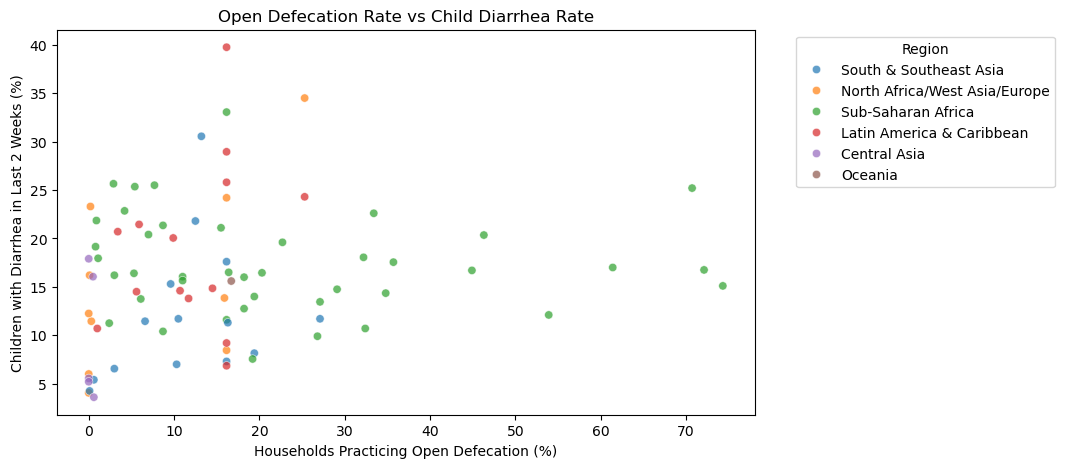

In [89]:
# scatter plot: open defecation rate vs child diarrhea rate, colored by region
plt.figure(figsize=(9, 5))
sns.scatterplot(
    x="open_defecation_hh_pct",
    y="diarrhea_rate",
    hue="region",   # color each dot by geographic region
    data=plot_df,
    alpha=0.7  # slight transparency to show overlapping points
)
plt.title("Open Defecation Rate vs Child Diarrhea Rate")
plt.xlabel("Households Practicing Open Defecation (%)")
plt.ylabel("Children with Diarrhea in Last 2 Weeks (%)")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [90]:
# Open defecation vs under-5 mortality
plot_df2 = latest.dropna(subset=["open_defecation_hh_pct", "u5_mortality", "region"])

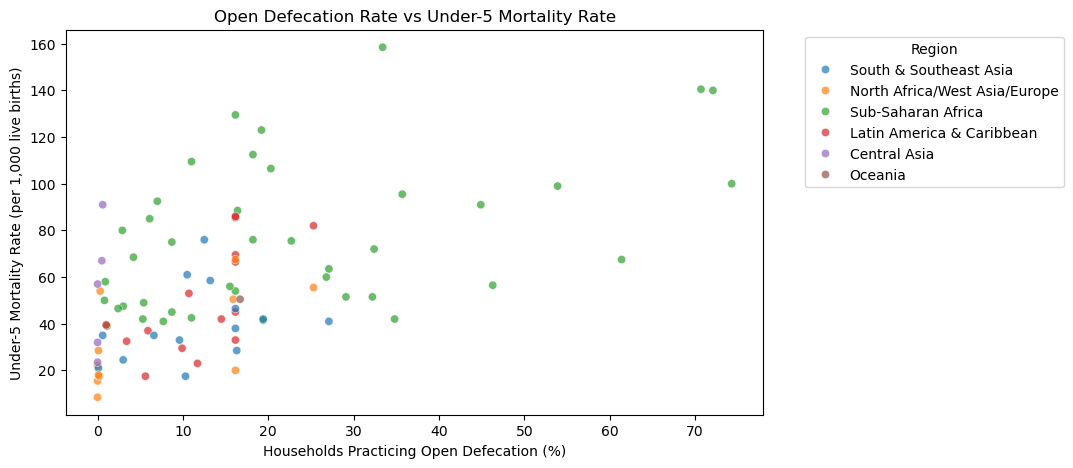

In [91]:
# scatter plot: open defecation rate vs under-5 mortality rate, colored by region
plt.figure(figsize=(9, 5))
sns.scatterplot(
    x="open_defecation_hh_pct",
    y="u5_mortality",
    hue="region",   # color each dot by geographic region
    data=plot_df2,
    alpha=0.7     # slight transparency to show overlapping points
)
plt.title("Open Defecation Rate vs Under-5 Mortality Rate")
plt.xlabel("Households Practicing Open Defecation (%)")
plt.ylabel("Under-5 Mortality Rate (per 1,000 live births)")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [92]:
# Correlation Heatmap of WASH indicators and health outcomes
heatmap_cols = [
    # WASH inputs
    "improved_water_pct",
    "improved_sanitation_pct",
    "open_defecation_hh_pct",
    "piped_water_pct",
    "surface_water_pct",
    "water_over30min_pct",
    # Disease & health outcomes
    "diarrhea_rate",
    "u5_mortality",
    "infant_mortality",
    "neonatal_mortality",
    # Controls
    "electricity_pct",
    "gdp_per_capita",
    "life_expectancy",
]

In [93]:
# Only keep columns that exist after data quality cleaning
valid_heatmap_cols = []
for c in heatmap_cols:
    if c in final_df.columns:
        valid_heatmap_cols.append(c)

heatmap_cols = valid_heatmap_cols

In [94]:
# drop rows where all heatmap columns are missing before computing correlations
corr_df = final_df[heatmap_cols].dropna(how="all")

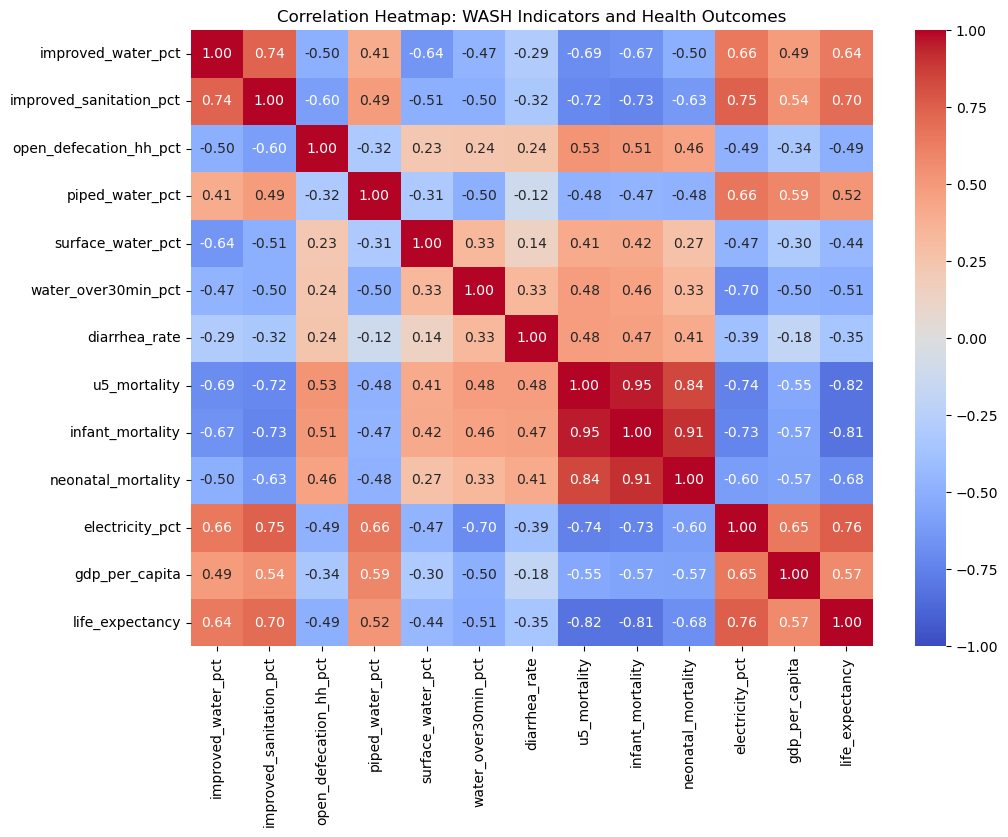

In [95]:
# correlation heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_df.corr(),
    annot=True,    # show values inside each cell
    fmt=".2f",    # round to 2 decimal places
    vmin=-1,
    vmax=1,
    center=0,    # center the color scale at 0
    cmap="coolwarm"
)
plt.title("Correlation Heatmap: WASH Indicators and Health Outcomes")
plt.show()

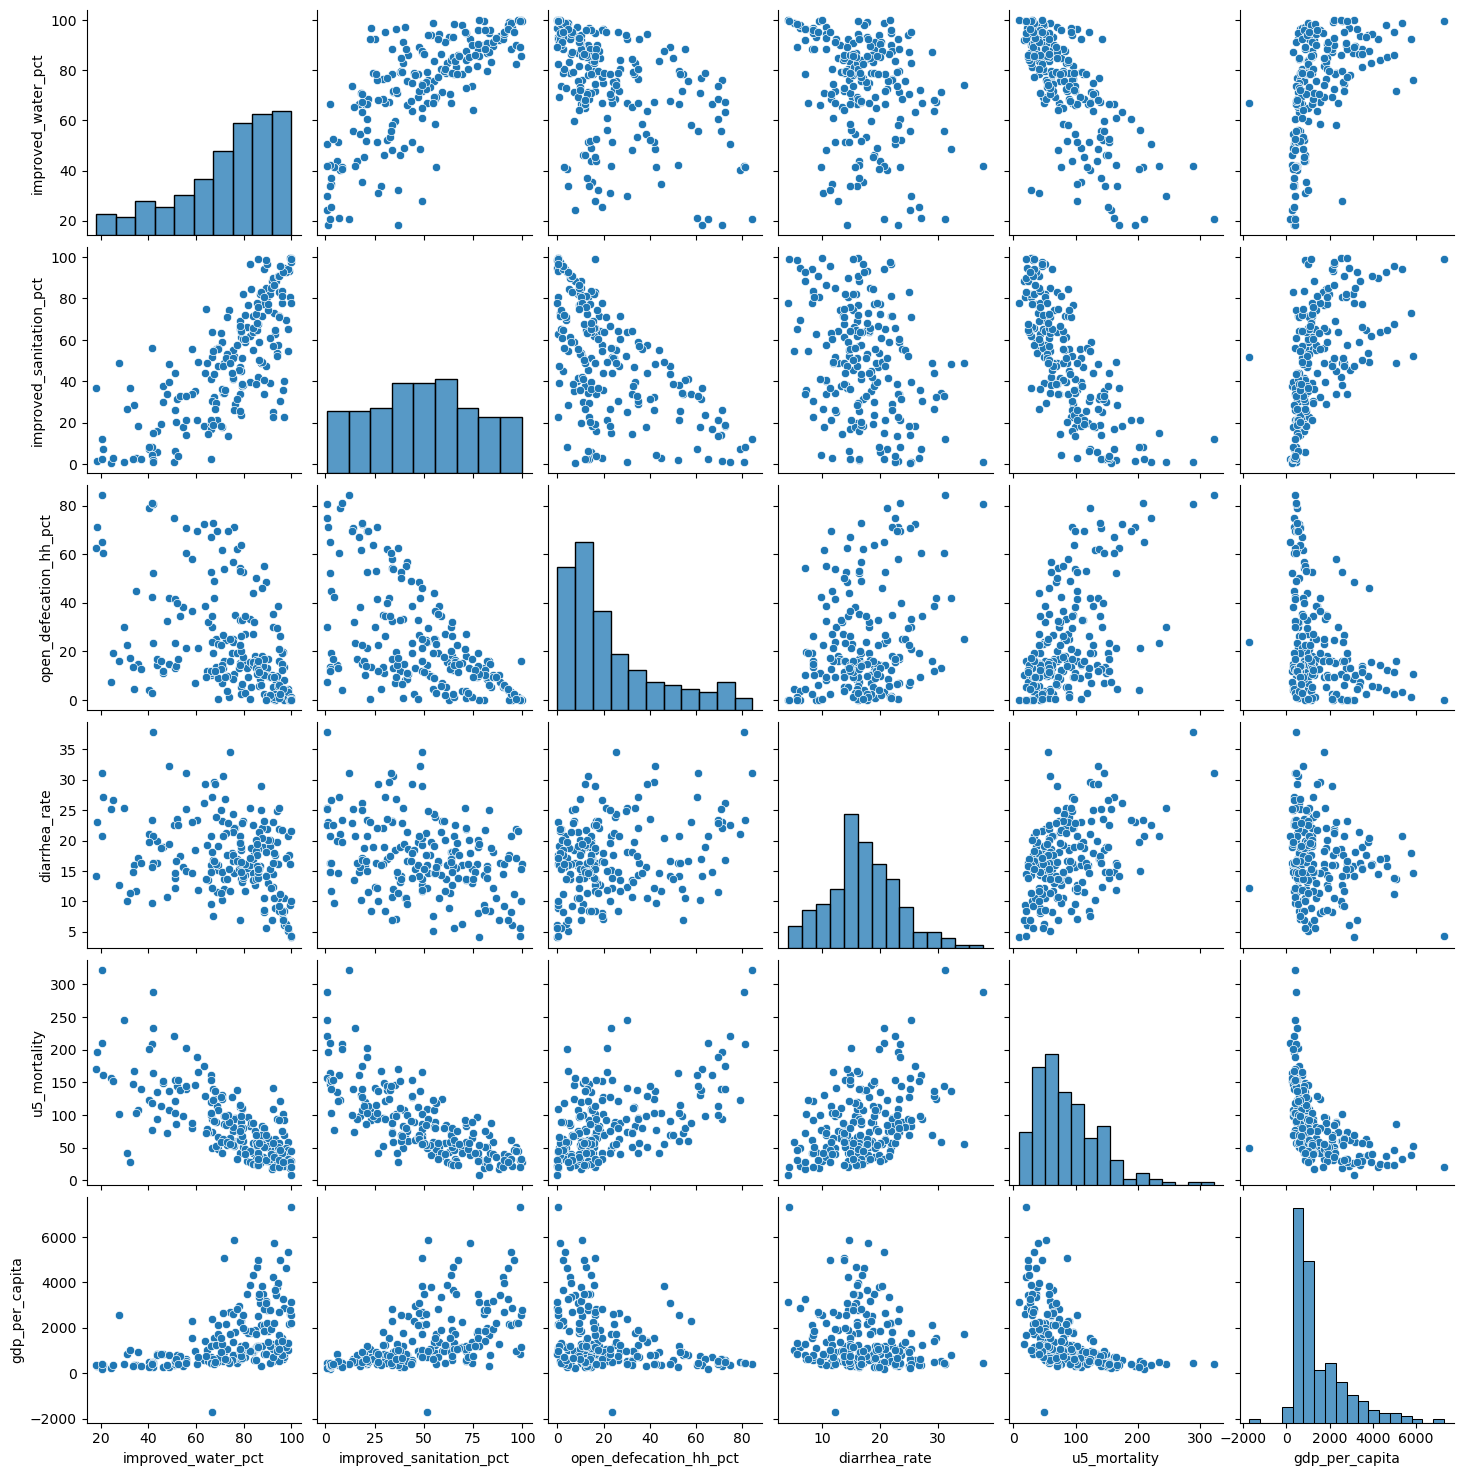

In [96]:
# Pairplot of key sanitation indicators and health outcomes
pairplot_cols = [
    "improved_water_pct",
    "improved_sanitation_pct",
    "open_defecation_hh_pct",
    "diarrhea_rate",
    "u5_mortality",
    "gdp_per_capita"
]

sns.pairplot(
    final_df[pairplot_cols].dropna()   # drop rows missing any of these columns
)
plt.show()

# Conclusion:

This analysis shows that sanitation and water access are strongly linked to child health outcomes across countries. Countries with higher access to improved sanitation and water consistently have lower rates of under-5 mortality and diarrhea, while open defecation emerges as one of the most harmful factors. At the same time, the results highlight that GDP plays an important role, as higher-income countries tend to have significantly better WASH conditions. This suggests that both infrastructure investment and broader economic development matter for improving health outcomes.

The well-pooped index provides a useful way to summarise overall sanitation and hygiene conditions into a single index. Using this index, we observe that global sanitation conditions have improved over time, although early years should be interpreted cautiously due to limited data coverage.

From a policy perspective, the findings suggest that targeting reductions in open defecation and improving sanitation access in low-income countries should be a top priority, as these areas are most strongly associated with poor health outcomes.

The stacked bar chart indicates policymakers should prioritise to increase the access to handwashing and sanitation facilities, which is much less than 